# Natural Language Processing
## Assignment 1 - Group 17

*_Adriano Machado (up202105352), Félix Martins (up202108837), Francisco da Ana (up202108762)_*  


### Overview
This assignment applies fundamental NLP techniques to solve a text classification problem without relying on deep learning architectures.

This notebook follows the following workflow:

1. **Data Exploration**: Understanding the dataset's characteristics through visualizations and statistical analysis
2. **Pre-processing Pipeline**: Implementing text normalization, cleaning, and feature extraction
3. **Feature Representation**: Experimenting with both sparse (e.g., TF-IDF) and dense (e.g., word embeddings) representations
4. **Model Selection**: Testing various classical ML algorithms (Naive Bayes, Logistic Regression, SVM, etc.)
5. **Evaluation & Refinement**: Measuring performance, analyzing errors, and iteratively improving the models


## Data Provenance and Characteristics

The [Polite Guard dataset](https://github.com/intel/polite-guard) is a specialized corpus developed by Intel for **politeness classification** in text. This dataset serves as the foundation for our NLP classification task.

### Data Sources and Collection

The dataset comprises three distinct components:
- **50,000 samples** generated using Few-Shot prompting
- **50,000 samples** generated using Chain-of-Thought (CoT) prompting
- **200 annotated samples** from corporate trainings (with personal identifiers removed)

The dataset is primarily synthetic, created using large language models (LLMs) to simulate customer service interactions across various sectors, such as finance, travel, food and drink, sports, etc. 


### Annotation Process

The dataset features a four-category classification system:
1. **Polite**: Text showing consideration, respect, and good manners with courteous phrases and friendly tone
2. **Somewhat Polite**: Generally respectful text lacking warmth or formality but maintaining a decent level of courtesy
3. **Neutral**: Straightforward and factual text without emotional undertones or specific attempts at politeness
4. **Impolite**: Disrespectful or rude text, often blunt or dismissive, showing lack of consideration


### Data Generation Process
- **Synthetic Data**: Generated through language models (Llama 3.1 8B-Instruct, Gemma 2 9B-It, Mixtral 8x7B-Instruct-v0.1) with specific instructions to create text matching the desired politeness category
- **Real Data**: The 200 real-world samples were collected from corporate trainings and manually annotated

### Data Structure

Each example in the dataset contains:
- **text**: The input text string
- **label**: The classification label (polite, somewhat polite, neutral, impolite)
- **source**: The language model used for generation or "LMS" for corporate training samples
- **reasoning**: The rationale provided by the language model for the generated text (for synthetic samples)

## Exploratory Data Analysis

In [25]:
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     /home/minipoloalex/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/minipoloalex/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/minipoloalex/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/minipoloalex/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/minipoloalex/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [26]:
file_paths = {
    'train_cot': 'data/train/train_cot.csv',
    'train_few_shot': 'data/train/train_few_shot.csv',
    'val_cot': 'data/validation/val_cot.csv',
    'val_few_shot': 'data/validation/val_few_shot.csv',
    'test_cot': 'data/test/test_cot.csv',
    'test_few_shot': 'data/test/test_few_shot.csv',
    'test_LMs': 'data/test/test_lms.csv'
}

sns.set_palette("crest")

dataframes = {}
for name, path in file_paths.items():
    dataframes[name] = pd.read_csv(path)

In [27]:
table_data = []
for name, df in dataframes.items():
    shape = df.shape
    columns = ', '.join(df.columns)
    missing_values = df.isnull().sum().to_dict()
    duplicates = df.duplicated().sum()
    
    table_data.append({
        'Dataset': name,
        'Rows': f"{shape[0]}",
        'Duplicates': duplicates,
        'Missing Values': str(missing_values),
    })

table_df = pd.DataFrame(table_data)
table_df

,Dataset,Rows,Duplicates,Missing Values
0,train_cot,40000,0,"{'text': 0, 'label': 0, 'source': 0, 'reasonin..."
1,train_few_shot,40000,0,"{'text': 0, 'label': 0, 'source': 0, 'reasonin..."
2,val_cot,5000,0,"{'text': 0, 'label': 0, 'source': 0, 'reasonin..."
3,val_few_shot,5000,0,"{'text': 0, 'label': 0, 'source': 0, 'reasonin..."
4,test_cot,5000,0,"{'text': 0, 'label': 0, 'source': 0, 'reasonin..."
5,test_few_shot,5000,0,"{'text': 0, 'label': 0, 'source': 0, 'reasonin..."
6,test_LMs,200,0,"{'text': 0, 'label': 0, 'source': 0, 'reasonin..."


As we can see, there's no duplicates and no missing values in our dataset's.

There's about 80000(80%) instances of training, 10000(10%) instances of validation and 10000(10%) instances of test (plus 200 real world examples)

In order to better analyze the datasets, we'll merge the training, validation and test together

In [28]:
all_synthetic = pd.concat([dataframes['train_cot'], dataframes['train_few_shot'], dataframes['val_cot'], dataframes['val_few_shot'], dataframes['test_cot'], dataframes['test_few_shot']])

combined_dataframes = {
    'Synthetic data': all_synthetic,
    'Real data': dataframes['test_LMs']
}


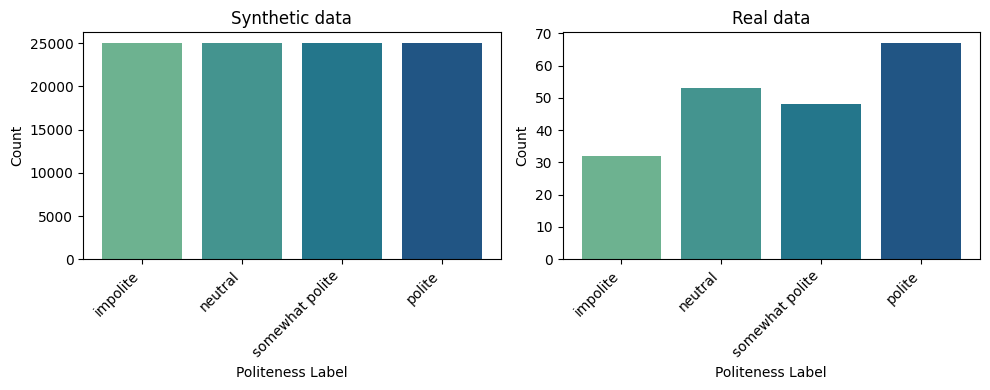

In [29]:
label_order = ['impolite', 'neutral', 'somewhat polite', 'polite']

plt.figure(figsize=(10, 4))
n_datasets = len(combined_dataframes)
for i, (name, df) in enumerate(combined_dataframes.items(), 1):
    if 'label' in df.columns:
        label_counts = Counter(df['label'].astype(str))
        labels = [l for l in label_order if l in label_counts]  
        counts = [label_counts[l] for l in labels if l in label_counts]
        
        plt.subplot(1, n_datasets, i)
        
        colors = sns.color_palette("crest", n_colors=len(labels))
        plt.bar(labels, counts, color=colors)
        
        plt.title(f'{name}')
        plt.xlabel('Politeness Label')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
    
plt.tight_layout()
plt.show()

The synthetic datasets exhibit similar distributions across politeness labels. However, the Real Dataset is slightly biased, with a higher count of "polite" and "neutral" labels compared to "impolite" and "somewhat polite."

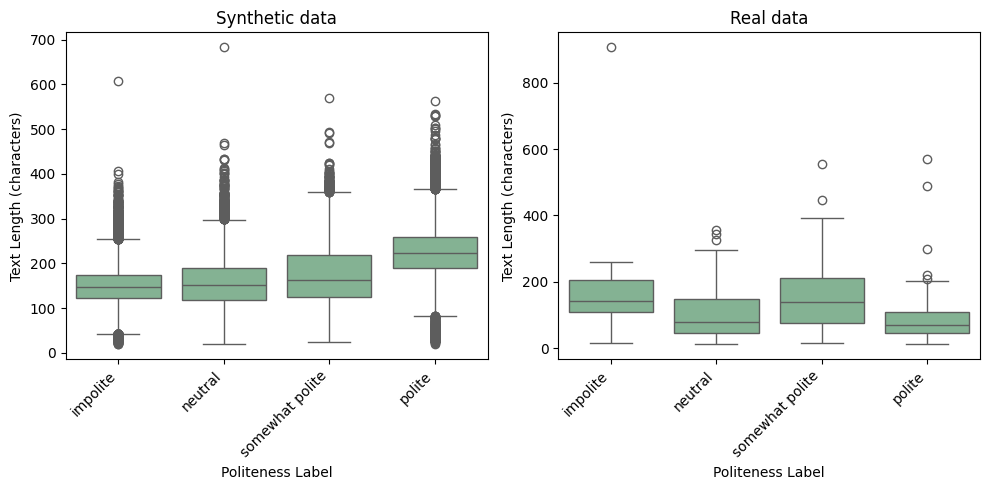

In [30]:
plt.figure(figsize=(10, 5))
for i, (name, df) in enumerate(combined_dataframes.items(), 1):
    if 'label' in df.columns and 'text' in df.columns:
        text_lengths = df['text'].astype(str).fillna('').str.len()
        
        plt.subplot(1, n_datasets, i)
        sns.boxplot(data=df, x='label', y=text_lengths, order=label_order)
        plt.title(f'{name}')
        plt.xlabel('Politeness Label')
        plt.ylabel('Text Length (characters)')
        plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In synthetic datasets, longer texts tend to be more polite, but this pattern is absent in the real test set, suggesting potential biases or artificial correlations in the synthetic data.

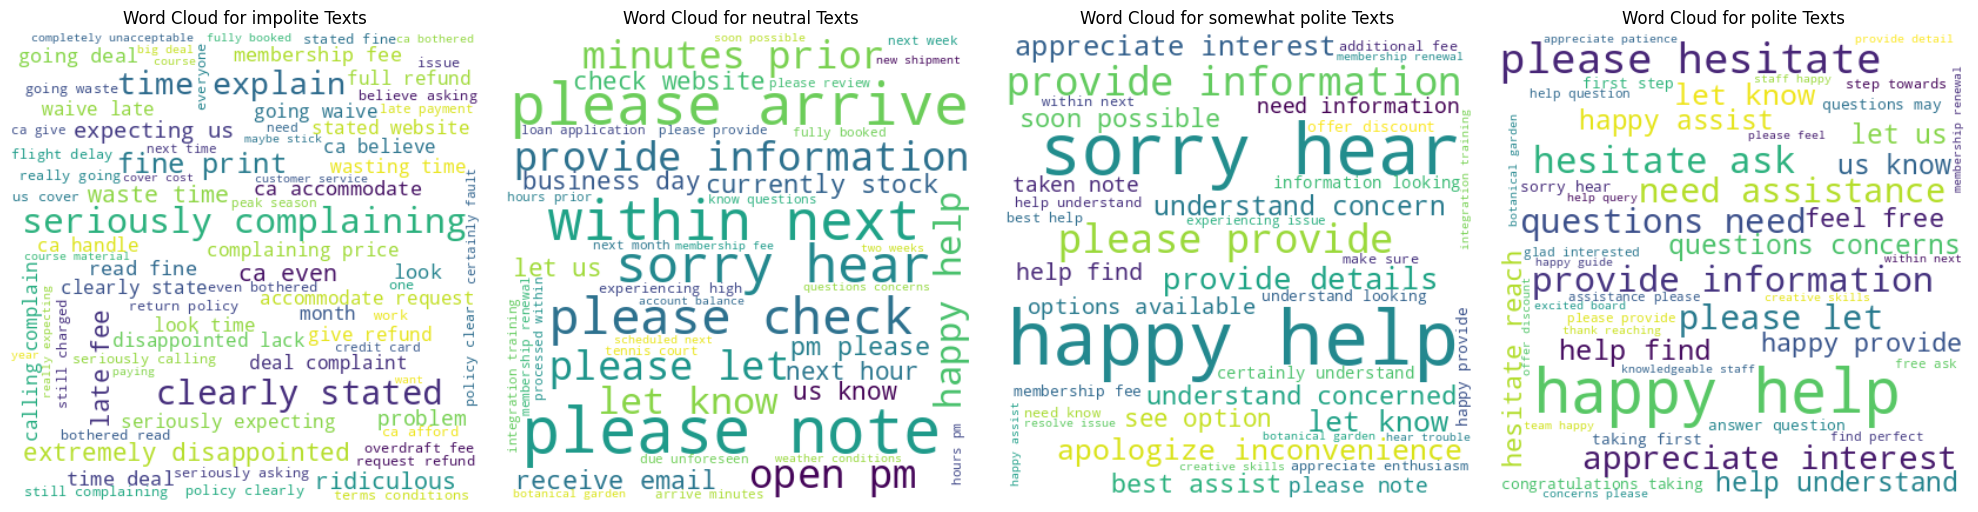

In [31]:
def generate_word_clouds(label_texts, label_order):
    num_labels = len(label_order)
    fig, axes = plt.subplots(1, num_labels, figsize=(5 * num_labels, 5)) 
    
    if num_labels == 1: 
        axes = [axes]

    for ax, label in zip(axes, label_order):
        if label_texts[label]: 
            stop_words = set(stopwords.words('english'))
            word_tokens = word_tokenize(' '.join(label_texts[label]))
            filtered_words = [word.lower() for word in word_tokens if word.lower() not in stop_words and word.isalnum()]
            
            wordcloud = WordCloud(width=400, height=400, background_color='white', min_font_size=10).generate(' '.join(filtered_words))

            ax.imshow(wordcloud, interpolation='bilinear')
            ax.set_title(f'Word Cloud for {label} Texts')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

label_texts = {label: [] for label in label_order}
for name, df in combined_dataframes.items():
    if 'label' in df.columns and 'text' in df.columns:
        for label in label_order:
            label_texts[label].extend(df[df['label'].astype(str) == label]['text'].dropna().tolist())


generate_word_clouds(label_texts, label_order)

Impolite texts reflect frustration with words like "seriously" and "ridiculous." Neutral texts use factual, procedural words such as "please" and "note". Somewhat polite texts soften messages with apologies like "sorry" and "hear". Polite texts emphasize helpfulness with phrases like "happy" and "assistance".



In [32]:
def get_top_ngrams(texts, n=1, top_k=20):
    stop_words = set(stopwords.words('english'))
    all_ngrams = []
    
    for text in texts:
        tokens = [token.lower() for token in word_tokenize(text) 
                 if token.isalnum() and token.lower() not in stop_words]
        
        text_ngrams = list(ngrams(tokens, n))
        all_ngrams.extend(text_ngrams)
    
    ngram_freq = Counter(all_ngrams)
    
    return ngram_freq.most_common(top_k)

In [33]:
def plot_top_ngrams(label_texts, label_order, n=1, top_k=15):
    fig, axes = plt.subplots(1, len(label_order), figsize=(6 * len(label_order), 6))
    
    for i, label in enumerate(label_order):
        ax = axes[i]
        if not label_texts[label]:
            ax.text(0.5, 0.5, f"No data for {label}", ha='center', va='center')
            ax.set_title(f"Top {top_k} {n}-grams for {label}")
            ax.axis('off')
            continue
            
        top_ngrams = get_top_ngrams(label_texts[label], n, top_k)
        
        if n > 1:
            labels = [' '.join(ng[0]) for ng in top_ngrams]
        else:
            labels = [ng[0][0] for ng in top_ngrams]
            
        values = [ng[1] for ng in top_ngrams]
        
        bars = ax.barh(range(len(labels)), values, color=sns.color_palette("crest", n_colors=1)[0])
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels)
        ax.invert_yaxis() 
        ax.set_title(f"Top {top_k} {n}-grams for {label}")
        
        for bar in bars:
            width = bar.get_width()
            ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f"{int(width)}", 
                    ha='left', va='center')
    
    plt.tight_layout()
    return fig

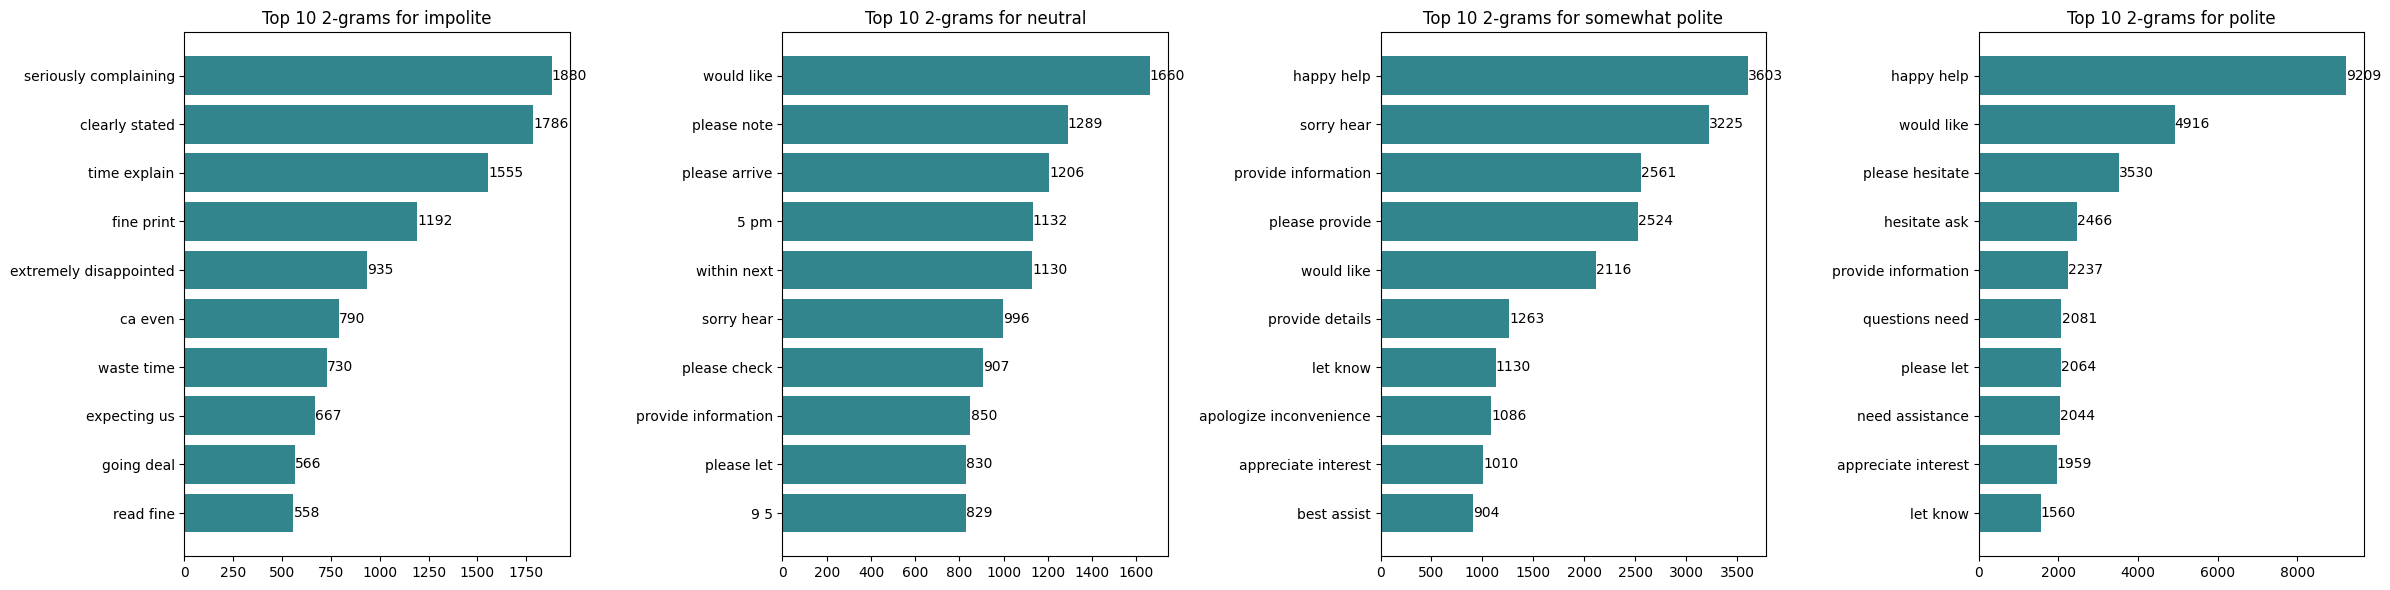

In [34]:
unigram_fig = plot_top_ngrams(label_texts, label_order, n=2, top_k=10)
plt.show()

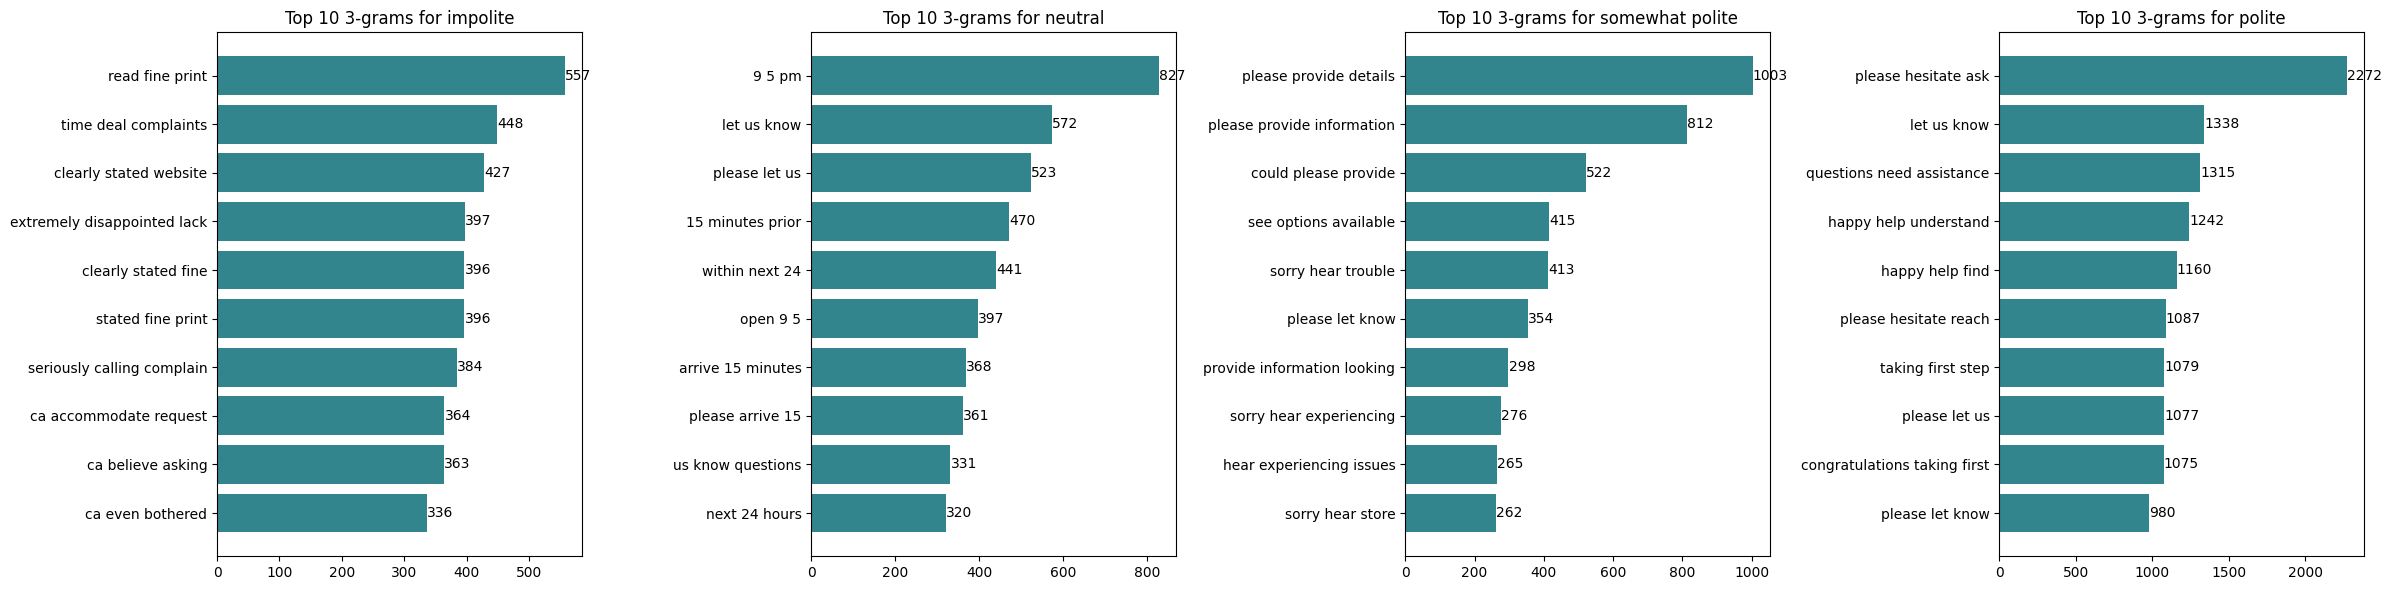

In [35]:
unigram_fig = plot_top_ngrams(label_texts, label_order, n=3, top_k=10)
plt.show()

Analyzing the 3-gram we notice some linguistic patterns: 

- "impolite" texts show frustration (e.g., "read fine print", "time deal complaints")
- "neutral" are more factual (e.g., "9:5 pm")
- while "somewhat polite" (e.g., "please provide details") and "polite" (e.g., "please hesitate ask") texts reflect increasing courtesy

Let's now perform sentiment analysis on the dataset.

In [36]:
def analyze_sentiment_subjectivity_for_plotting(df, label_order):
    sentiment_data_plot = {}
    for label in label_order:
        label_df = df[df['label'].astype(str) == label]['text'].dropna()
        polarities = []
        subjectivities = []
        for text in label_df:
            blob = TextBlob(text)
            polarities.append(blob.sentiment.polarity)
            subjectivities.append(blob.sentiment.subjectivity)
        sentiment_data_plot[label] = {'polarity': polarities, 'subjectivity': subjectivities}
    return sentiment_data_plot


In [37]:
sentiment_plot_results = {}
for name, df in combined_dataframes.items():
    if 'label' in df.columns and 'text' in df.columns:
        print(f"\nProcessing: {name}")
        sentiment_plot_results[name] = analyze_sentiment_subjectivity_for_plotting(df, label_order)


Processing: Synthetic data

Processing: Real data


In [38]:
def visualize_sentiment_by_type(sentiment_plot_results, label_order, plot_type):
    """
    plot_type (str): 'polarity' or 'subjectivity' to specify which metric to plot
    """
    if plot_type not in ['polarity', 'subjectivity']:
        raise ValueError("plot_type must be either 'polarity' or 'subjectivity'")
        
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    if plot_type == 'polarity':
        plot_title = 'Sentiment Polarity by Politeness Level'
        ylabel = 'Sentiment Polarity (-1 to 1)'
        annotation = 'Polarity: -1 (negative) to 1 (positive)'
    else:  
        plot_title = 'Subjectivity by Politeness Level'
        ylabel = 'Subjectivity (0 to 1)'
        annotation = 'Subjectivity: 0 (objective) to 1 (subjective)'
    

    datasets = list(sentiment_plot_results.keys())
    colors = sns.color_palette("crest", n_colors=len(label_order))
    
    for d, dataset in enumerate(datasets):
        data_to_plot = []
        for j, label in enumerate(label_order):
            if label in sentiment_plot_results[dataset]:
                values = sentiment_plot_results[dataset][label][plot_type]
                if values:
                    data_to_plot.append(values)
                else:
                    data_to_plot.append([])
            else:
                data_to_plot.append([])
        
        bp = axs[d].boxplot(data_to_plot, patch_artist=True, tick_labels=label_order)
        
        for j, box in enumerate(bp['boxes']):
            box.set(facecolor=colors[j])
        
        axs[d].set_title(f"{plot_title} - {dataset}", fontsize=10)
        axs[d].set_ylabel(ylabel, fontsize=9)
        axs[d].set_xticklabels(label_order, rotation=45, ha='right', fontsize=8)
        

    fig.text(0.5, 0.01, annotation, ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)
    plt.show()


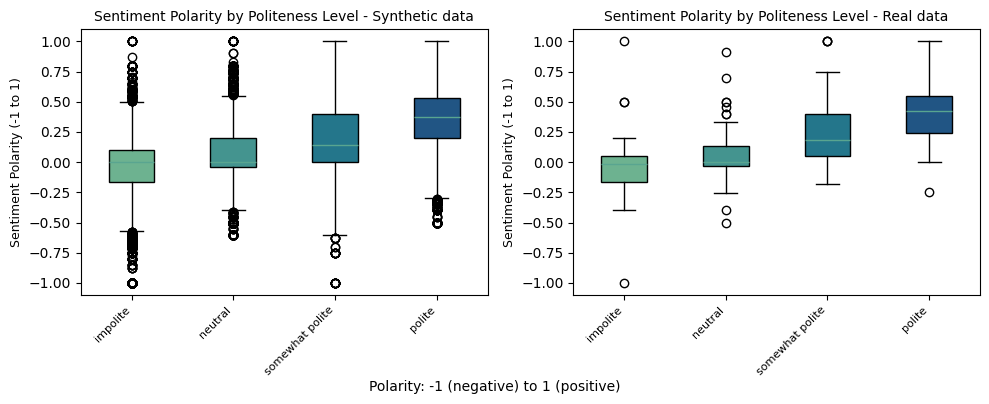

In [39]:
visualize_sentiment_by_type(sentiment_plot_results, label_order, 'polarity')

As we can see the sentiment polarity is directly related to the politeness label, with "polite" texts being more positive and "impolite" texts being more negative.

This relationship is similar in synthetic and real datasets.

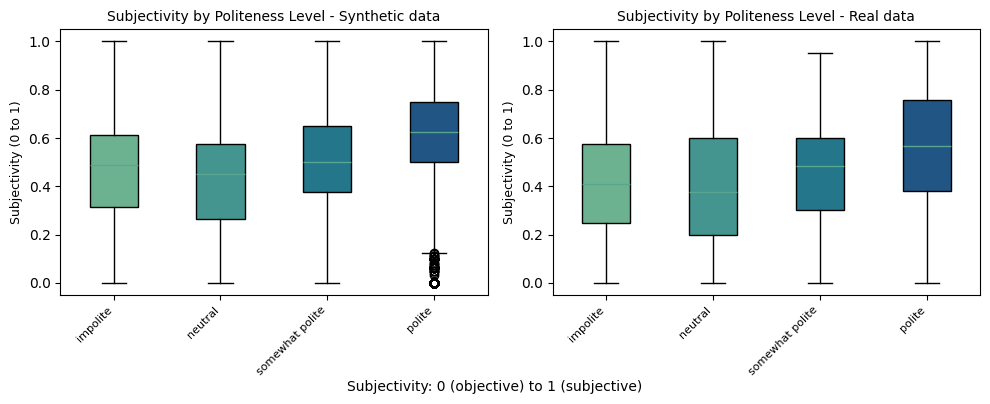

In [40]:
visualize_sentiment_by_type(sentiment_plot_results, label_order, 'subjectivity')

In terms of subjectivity the relationship is less clear, but polite texts tend to be more subjective than impolite ones. 

## Preprocessing and feature representation techniques

**Feature extraction**
- Bag of words (n=1 without stop words, n=2 with stop word)
- TF-IDF
- (Word embeddings)

**Data preprocessing**
- Tokenization
- Case folding (lowercasing)
- Removing punctuation and special characters
- Lemmatization

In [41]:
import nltk
from nltk import word_tokenize, pos_tag
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
import re

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()
sw = set(stopwords.words('english'))

# Function to convert NLTK POS tags to WordNet POS tags
def get_wordnet_pos(nltk_tag):
    """
    Convert NLTK POS tags to WordNet POS tags.

    Parameters:
        nltk_tag (str): Part-of-speech tag in Penn Treebank format

    Returns:
        wordnet-POS-constant: The corresponding WordNet POS tag
    """
    tag_to_wordnet = {
        'J': wordnet.ADJ,
        'V': wordnet.VERB,
        'N': wordnet.NOUN,
        'R': wordnet.ADV
    }
    # Default is noun
    return tag_to_wordnet.get(nltk_tag[0], wordnet.NOUN)

def preprocess_text(review, include_sw=False):
    """
    Preprocess text data for NLP tasks:
    1- Removes non-alphabetic characters
    2- Converts text to lowercase
    3- Tokenizes text
    4- Removes stopwords (optional)
    5- Uses lemmatization with POS tagging.

    Parameters:
        text (str): Input text to be preprocessed
        include_sw (bool): Whether to include stopwords in the result
                           Default is False (stopwords are removed)
    Returns:
        str: Preprocessed text with lemmatized words joined by spaces
    """
    # Remove non-alphabetic characters
    review = re.sub('[^a-zA-Z]', ' ', review)  # TODO: include (or not) numbers
    review = review.lower()

    # Tokenize
    words = word_tokenize(review)

    # POS (Part-of-speech) tagging
    tagged_words = pos_tag(words)

    # Lemmatize with POS tags
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(pos_tag)) 
                        for word, pos_tag in tagged_words 
                        if word not in sw or include_sw]
    return ' '.join(lemmatized_words)

In [42]:
print(dataframes["train_cot"]["text"][0])
print(preprocess_text(dataframes["train_cot"]["text"][0]))

Your flight has been rescheduled for 10:00 AM tomorrow. Please check the airport's website for any updates or changes.
flight reschedule tomorrow please check airport website update change


In [ ]:
all_dataframes = pd.concat(dataframes.values()).reset_index(drop=True)

cnt_base = defaultdict(int)
cnt_preprocessed = defaultdict(int)
cnt_preprocessed_sw = defaultdict(int)
for index, row in all_dataframes.iterrows():
    for word in word_tokenize(row['text']):
        cnt_base[word] += 1

    preprocessed = preprocess_text(row['text'])
    for word in preprocessed.split():
        cnt_preprocessed[word] += 1

    preprocessed_sw = preprocess_text(row['text'], include_sw=True)
    for word in preprocessed_sw.split():
        cnt_preprocessed_sw[word] += 1

print(f"Without preprocessing: {len(cnt_base)} words")
print(f"With preprocessing: {len(cnt_preprocessed_sw)} words (with stopwords)")
print(f"With preprocessing: {len(cnt_preprocessed)} words (no stopwords)")

Without preprocessing: 10943 words
With preprocessing: 6811 words (no stopwords)
With preprocessing: 6932 words (with stopwords)


In [45]:
def preprocess_dataframe(dataframes, feature, target):
    """
    Applies the text preprocessing function to the specified feature column in the dataframes.clear

    Parameters:
        dataframes (list): A list of pandas DataFrames
        feature (str): The name of the feature column to preprocess
        target (str): The name of the target column
    
    Returns:
        pd.DataFrame: A concatenated DataFrame with the preprocessed feature and target columns from all input DataFrames
    """
    result = pd.DataFrame()
    for df in dataframes:
        df[feature] = df[feature].apply(preprocess_text)
        result = pd.concat([result, df[[feature, target]]])
    return result

def extract_features(dataframes, feature, target, feature_extractor, *, train):
    """
    Extracts features from the specified feature column in the dataframes using a given feature extractor method.
    For example, the feature extractor could be a TF-IDF vectorizer or a Bag-of-Words algorithm.

    Parameters:
        dataframes (list): A list of pandas DataFrames
        feature (str): The name of the feature column to extract features from
        target (str): The name of the target column
        feature_extractor (callable): A function that takes a list of texts and returns a list of feature vectors
        train (bool): Whether the feature extractor should be trained (fit) or not
    Returns:
        pd.DataFrame: A concatenated DataFrame with the extracted features and target columns from all input DataFrames
    """
    cleaned_data = preprocess_dataframe(dataframes, feature, target)  # This is a DataFrame with preprocessed text
    if train:
        feature_extractor.fit(cleaned_data[feature])
    feature_matrix = feature_extractor.transform(cleaned_data[feature])
    feature_df = pd.DataFrame(feature_matrix.toarray(), columns=feature_extractor.get_feature_names_out())
    feature_df[target] = cleaned_data[target].values
    return feature_df

In [73]:
bag_of_words = CountVectorizer()
train_data_bow = extract_features([dataframes['train_cot'], dataframes['train_few_shot']], 'text', 'label', bag_of_words, train=True)
val_data_bow = extract_features([dataframes['val_cot'], dataframes['val_few_shot']], 'text', 'label', bag_of_words, train=False)
test_data_bow = extract_features([dataframes['test_cot'], dataframes['test_few_shot'], dataframes['test_LMs']], 'text', 'label', bag_of_words, train=False)

In [98]:
print(train_data_bow.shape)
print(val_data_bow.shape)
print(test_data_bow.shape)

(80000, 5959)
(10000, 5959)
(10200, 5959)


## Classification Models

**ML Algorithms**
- Naive Bayes
- Logistic Regression
- SVM

# TODO: scale features to use in Logistic Regression and SVM

In [ ]:
def train_model(model, train_data, val_data):
    """
    Trains a given model on the training data and evaluates it on the validation data.

    Parameters:
        train_data (pd.DataFrame): The training data with features and target
        val_data (pd.DataFrame): The validation data with features and target
        model (object): An instance of a scikit-learn model with fit and predict methods

    Returns:
        float: The accuracy of the model on the validation data
    """
    model.fit(train_data.drop('label', axis=1), train_data['label'])
    y_pred = model.predict(val_data.drop('label', axis=1))
    return accuracy_score(val_data['label'], y_pred)

def tune_hyperparameters(model, train_data, val_data, hyperparam_grid):
    """
    Tune the hyperparameters of a given model using grid search.
    Does not perform cross validation, because the training and validation data are completely separate in the dataset.

    Parameters:
        model (object): An instance of a scikit-learn model with fit and predict methods
        train_data (pd.DataFrame): The training data with features and target
        val_data (pd.DataFrame): The validation data with features and target
        hyperparam_grid (dict): A dictionary with hyperparameters names as keys and lists of values as values

    Returns:
        dict: The best hyperparameters found by the search
    """
    best_score = 0
    best_params = None
    for params in ParameterGrid(hyperparam_grid):
        model.set_params(**params)
        score = train_model(model, train_data, val_data)
        print(f"Score: {score:.4f} for {params}")
        if score > best_score:
            best_score = score
            best_params = params
    return best_params, score

def test_model(model, best_params, train_data, test_data):
    """
    Trains a given model on the training data and evaluates it on the test data.

    Parameters:
        train_data (pd.DataFrame): The training data with features and target
        test_data (pd.DataFrame): The test data with features and target
        model (object): An instance of a scikit-learn model with fit and predict methods

    Returns:
        float: The accuracy of the model on the test data
    """
    model.set_params(**best_params)
    model.fit(train_data.drop('label', axis=1), train_data['label'])
    y_pred = model.predict(test_data.drop('label', axis=1))
    return accuracy_score(test_data['label'], y_pred)

In [85]:
nb = MultinomialNB()
train_model(nb, train_data_bow, val_data_bow)

0.7865

In [86]:
best_params_nb, val_score_nb = tune_hyperparameters(nb, train_data_bow, val_data_bow, {'alpha': [0.1, 0.5, 1.0, 1.5, 2.0]})
print(best_params_nb, val_score_nb)

Score: 0.7878 for {'alpha': 0.1}
Score: 0.7877 for {'alpha': 0.5}
Score: 0.7865 for {'alpha': 1.0}
Score: 0.7870 for {'alpha': 1.5}
Score: 0.7865 for {'alpha': 2.0}
{'alpha': 0.1} 0.7865


In [87]:
test_model(nb, best_params_nb, train_data_bow, test_data_bow)

0.7862745098039216

In [ ]:
svm = SVC()
train_model(svm, train_data_bow, val_data_bow)

0.8923

In [ ]:
# best_params_svm, val_score_svm = tune_hyperparameters(svm, train_data_bow, val_data_bow, {'C': [0.1, 1.0, 10.0], 'kernel': ['linear', 'rbf']})
# print(best_params_svm, val_score_svm)

In [ ]:
# test_model(svm, best_params_svm, train_data_bow, test_data_bow)

In [ ]:
lr = LogisticRegression(penalty='l2', n_jobs=-1)
train_model(lr, train_data_bow, val_data_bow)

/home/minipoloalex/Documents/NLP-assign1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8648

In [97]:
best_params_lr, val_score_lr = tune_hyperparameters(lr, train_data_bow, val_data_bow, {'C': [0.1, 1.0, 10.0], 'max_iter': [100, 200, 300]})
print(best_params_lr, val_score_lr)

Score: 0.8611 for {'C': 0.1, 'max_iter': 100}
Score: 0.8611 for {'C': 0.1, 'max_iter': 200}
Score: 0.8611 for {'C': 0.1, 'max_iter': 300}


/home/minipoloalex/Documents/NLP-assign1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Score: 0.8648 for {'C': 1.0, 'max_iter': 100}
Score: 0.8649 for {'C': 1.0, 'max_iter': 200}
Score: 0.8649 for {'C': 1.0, 'max_iter': 300}


/home/minipoloalex/Documents/NLP-assign1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Score: 0.8618 for {'C': 10.0, 'max_iter': 100}


/home/minipoloalex/Documents/NLP-assign1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Score: 0.8612 for {'C': 10.0, 'max_iter': 200}
Score: 0.8615 for {'C': 10.0, 'max_iter': 300}
{'C': 1.0, 'max_iter': 200} 0.8615


In [99]:
test_model(lr, best_params_lr, train_data_bow, test_data_bow)

0.8544117647058823

## Pseudocode for final results

In [ ]:
include_digits = (True,False)
feature_exctractions = ("BoW_1","BoW_2","TF-IDF","word_embedding(n)")
pcas = (0, n)
models = ("NB","SVM","LR")

for include_digit in include_digits:
    for feature_extraction in feature_exctractions:
        for pca in pcas:
            for model in models:
                """
                - BoW2 requires to include stop_words
                - PCA is not performed when feature_extraction is word_embedding
                - when model == SVM or model == LR features must be scaled
                """
                # hyperparameter tunning: using train_set and val_set
                # store best hyperparameters for each model and its val accuracy
                # store loop information


# get the loop structure with best val_acc
# test in the test set and get test_acc